# Data 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn import metrics
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import iplot
from warnings import filterwarnings

filterwarnings("ignore")

In [2]:
data = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df = pd.DataFrame(data)
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df_object = df.select_dtypes('object')
df_object.head(3)

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes


In [6]:
df_int = df.select_dtypes('int64')
df_int.head(3)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0


# EDA

In [7]:
cat = df.select_dtypes(['object']).columns
num = df.select_dtypes(['number']).columns
print(cat)
print(num)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [8]:
for i in cat:
    print(f"value of {i}: {set(df[i])}")

value of Attrition: {'Yes', 'No'}
value of BusinessTravel: {'Travel_Frequently', 'Non-Travel', 'Travel_Rarely'}
value of Department: {'Sales', 'Research & Development', 'Human Resources'}
value of EducationField: {'Medical', 'Marketing', 'Human Resources', 'Life Sciences', 'Other', 'Technical Degree'}
value of Gender: {'Male', 'Female'}
value of JobRole: {'Research Scientist', 'Manufacturing Director', 'Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Sales Executive', 'Manager', 'Research Director', 'Sales Representative'}
value of MaritalStatus: {'Married', 'Single', 'Divorced'}
value of Over18: {'Y'}
value of OverTime: {'Yes', 'No'}


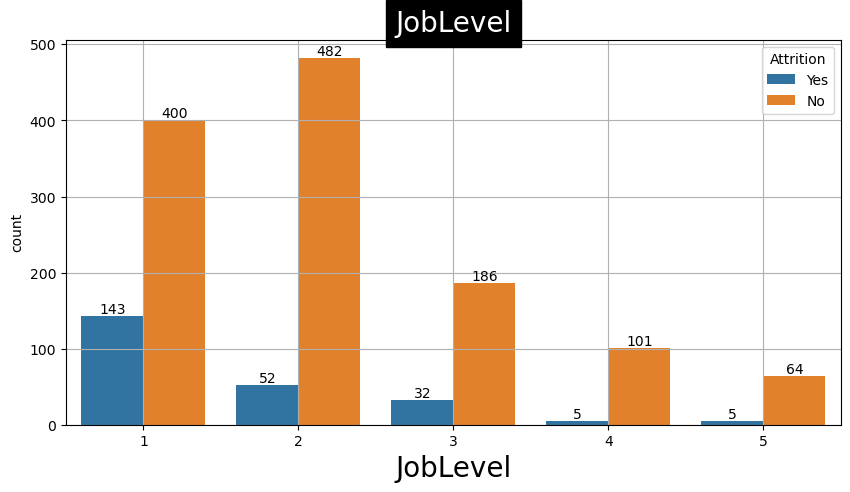

In [9]:
plt.figure(figsize=(10,5))

ax = sns.countplot(x=df['JobLevel'], data=df,hue="Attrition")
for container in ax.containers:
        ax.bar_label(container)
plt.title('JobLevel',backgroundcolor='black',color='white',fontsize=20)
plt.xlabel('JobLevel',fontsize=20)
plt.grid()
plt.show()

<Figure size 500x1000 with 0 Axes>

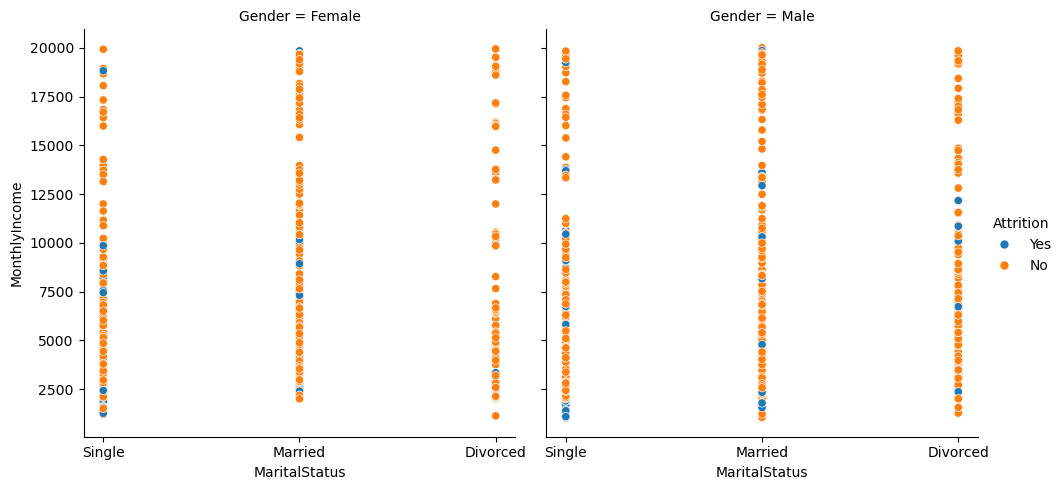

In [10]:
plt.figure(figsize=(5,10))
sns.relplot(data=df, y="MonthlyIncome", x="MaritalStatus", hue="Attrition",col='Gender')
plt.show()

이혼한 여성은 attrition을 잘 안함.

<Figure size 500x1000 with 0 Axes>

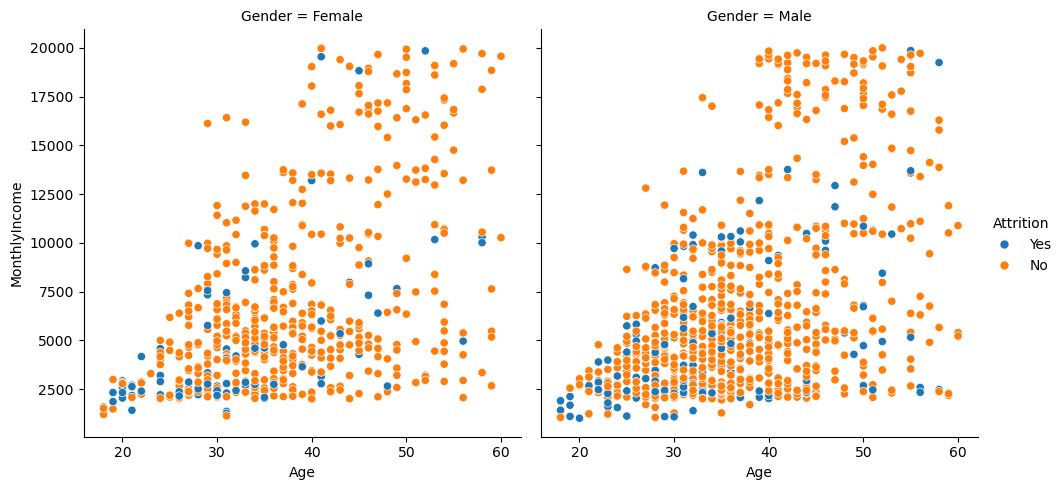

In [11]:
plt.figure(figsize=(5,10))
sns.relplot(data=df, y="MonthlyIncome", x="Age", hue="Attrition",col='Gender')
plt.show()

연봉과 attrition은 반비례 관계

<Figure size 1500x1000 with 0 Axes>

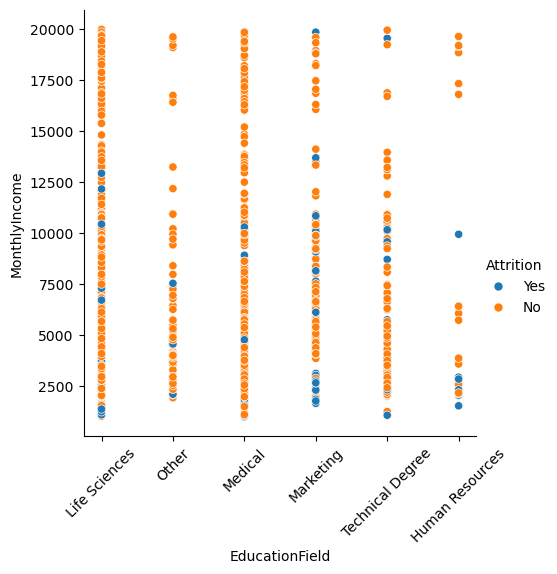

In [12]:
plt.figure(figsize=(15,10))
sns.relplot(data=df, y="MonthlyIncome", x="EducationField", hue="Attrition")
plt.xticks(rotation=45)
plt.show()

<Figure size 1500x1000 with 0 Axes>

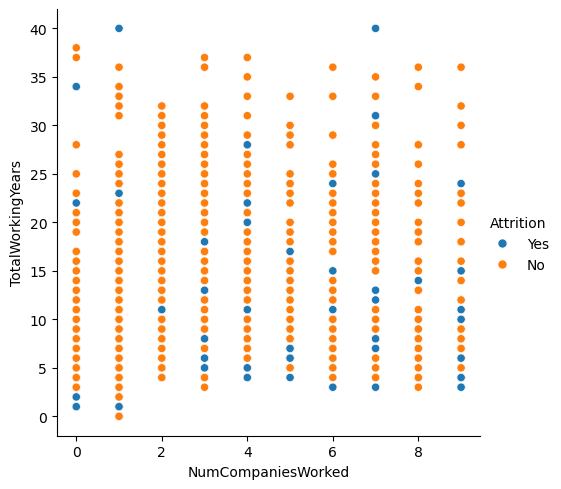

In [13]:
plt.figure(figsize=(15,10))
sns.relplot(data=df, y="TotalWorkingYears", x="NumCompaniesWorked", hue="Attrition")
plt.show()

TotalWorkingYears가 짧은 사람 중에서 NumCompaniesWorked가 많은 사람은 attrition을 많이 했다.<br>
**JobChangeRate = NumCompaniesWorked / TotalWorkingYears**

<Figure size 2500x1000 with 0 Axes>

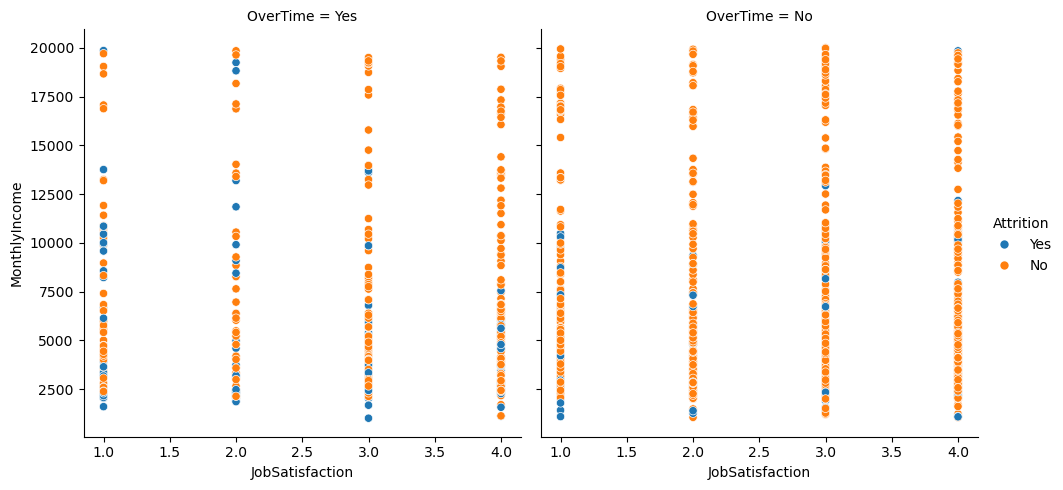

In [14]:
plt.figure(figsize=(25,10))
sns.relplot(data=df, y="MonthlyIncome", x="JobSatisfaction", hue="Attrition", col='OverTime')
plt.show()

<Figure size 2500x1000 with 0 Axes>

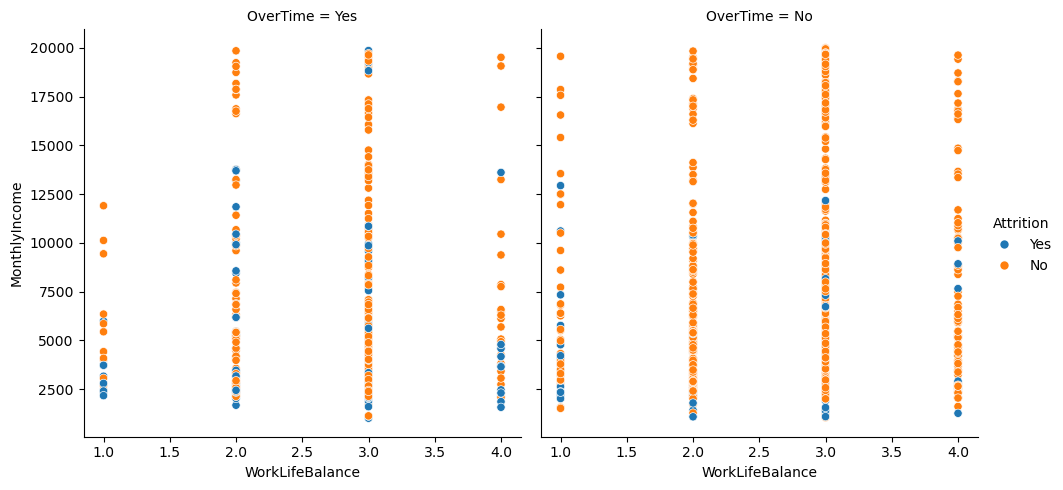

In [15]:
plt.figure(figsize=(25,10))
sns.relplot(data=df, y="MonthlyIncome", x="WorkLifeBalance", hue="Attrition", col='OverTime')
plt.show()

OverTime이 yes이고, jobsatisfaction, worklifebalance가 낮을 때, attrition은 많다.<br>
**StressScore = (OverTime + 1)/(JobSatisfaction + WorkLifeBalance)**

<Figure size 500x1000 with 0 Axes>

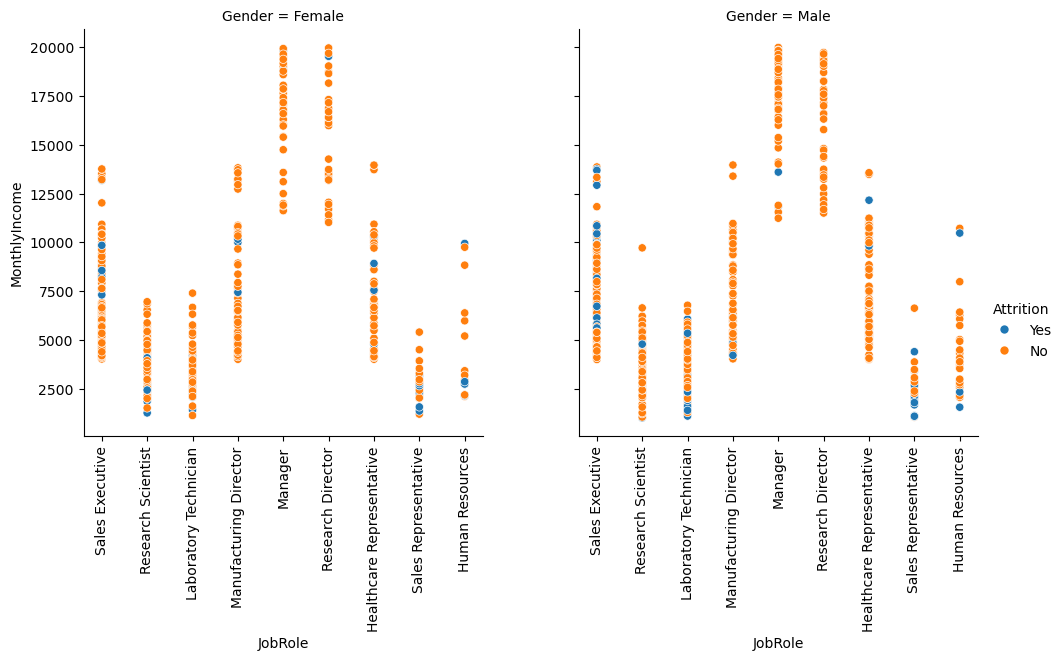

In [16]:
plt.figure(figsize=(5,10))
ax=sns.relplot(data=df, y="MonthlyIncome", x="JobRole", hue="Attrition",col='Gender')
rotation = 90 
for i, ax in enumerate(ax.fig.axes):   ## getting all axes of the fig object
     ax.set_xticklabels(ax.get_xticklabels(), rotation = rotation)
#plt.xticks(rotation=90)
plt.show()

여자는 laboratory technician, manager, research director일 때, attrition 잘 안 하고, <br>
남자는 research scientist, manager, research director일 때 attrition잘 안함

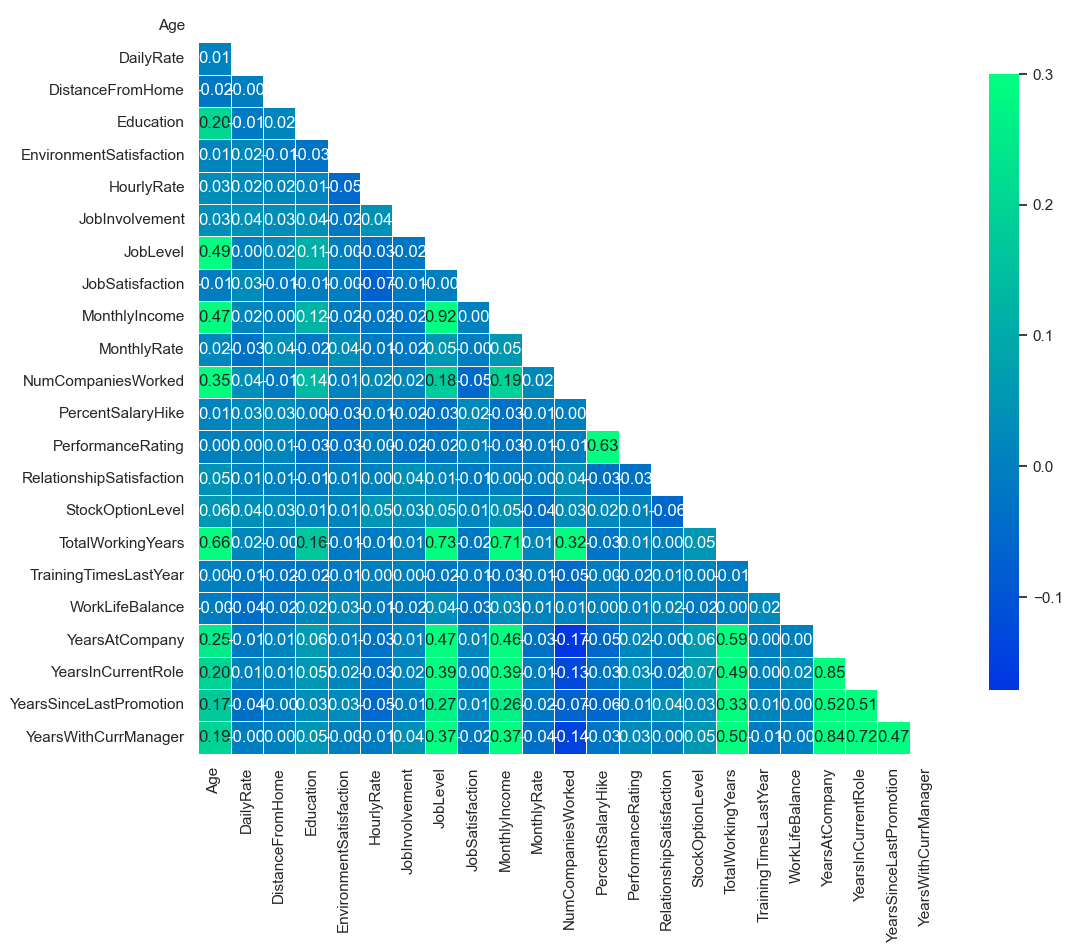

In [17]:
df_int_copy = df_int.copy()
df_int_copy = df_int_copy.drop(['EmployeeNumber','EmployeeCount','StandardHours'],axis=1)

corr = df_int_copy.corr(method = "spearman")
sns.set(style="white")

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 10), dpi = 100)
sns.heatmap(corr, mask = mask, cmap= "winter", vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, annot = True, fmt = ".2f")
plt.show()

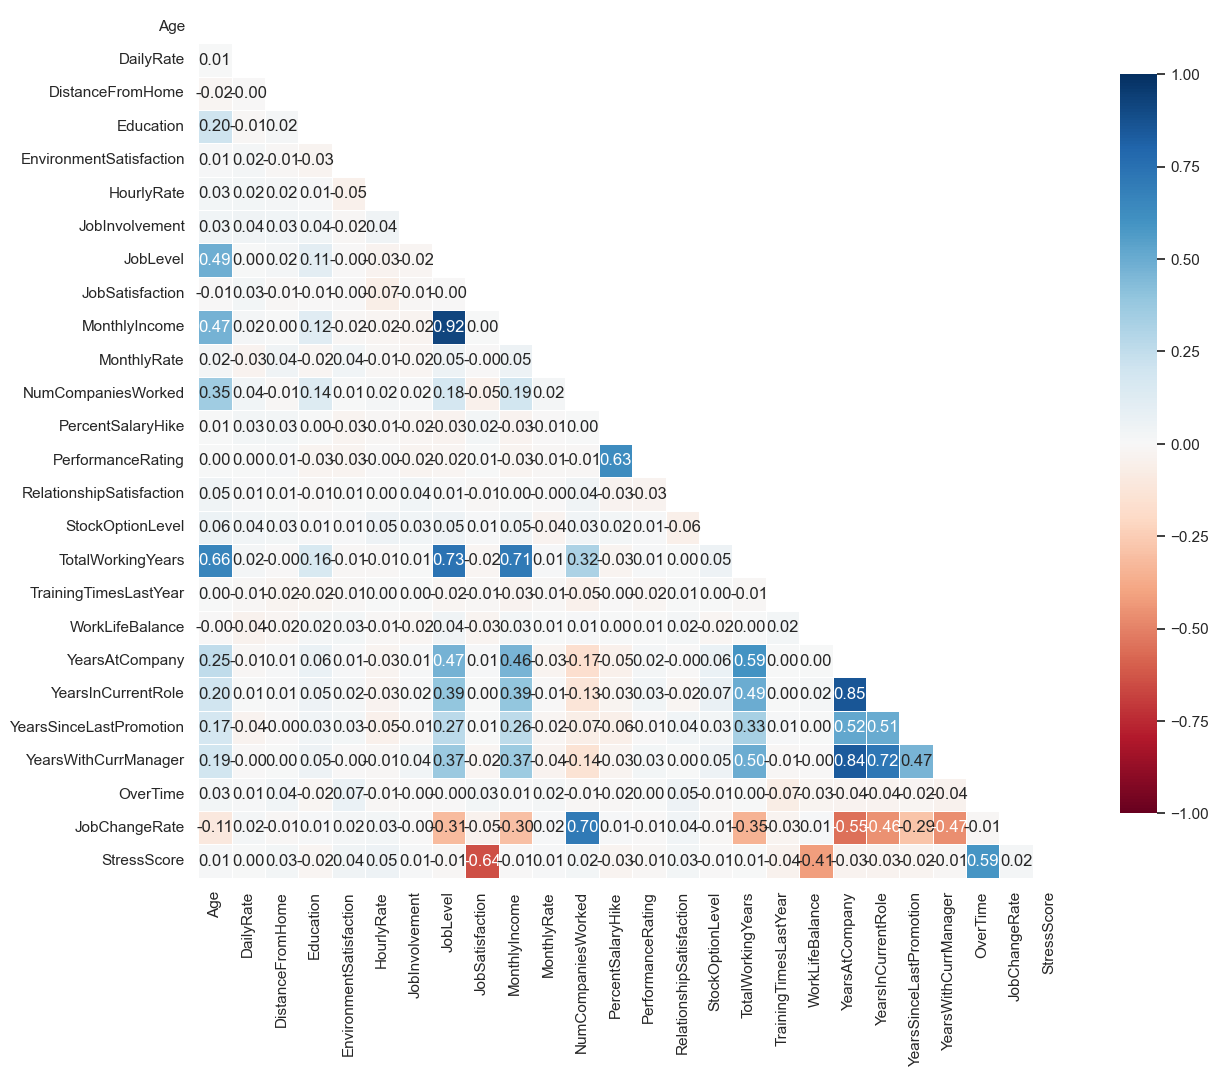

In [18]:
df_int_copy = df_int.copy()

DF = df.copy()

DF['OverTime'] = DF['OverTime'].replace('Yes',2)
DF['OverTime'] = DF['OverTime'].replace('No',1)
df_int_copy['OverTime'] = DF['OverTime']

# 새로운 피처 추가해서 상관관계 체크하고, 높으면 기존 피처들 drop
df_int_copy['JobChangeRate']=df_int_copy['NumCompaniesWorked']/df_int_copy['TotalWorkingYears']
df_int_copy['StressScore'] = (df_int_copy['OverTime']+1) / (df_int_copy['JobSatisfaction'] + df_int_copy['WorkLifeBalance'])

# 필요없는 feature들은 drop
df_int_copy = df_int_copy.drop(['EmployeeNumber','EmployeeCount','StandardHours'],axis=1)

corr = df_int_copy.corr(method = "spearman")
sns.set(style="white")

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 12), dpi = 100)
sns.heatmap(
    corr,
    mask = mask,
    cmap="RdBu",        # 또는 "RdBu", "bwr", "seismic" 추천
    vmin=-1,                # 최솟값 고정
    vmax=1,                 # 최댓값 고정
    center=0,               # 중심값 기준 0
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot=True,
    fmt=".2f"
)
plt.show()

JobChangeRate는 **NumCompaniesWorked와 0.70**, StressScore는 Jobsatisfaction과 0.64 <br>
피처 NumCompaniesWorked만 drop

In [19]:
DF = df.copy()
DF['BusinessTravel'] = DF['BusinessTravel'].replace('Travel_Rarely',2)
DF['BusinessTravel'] = DF['BusinessTravel'].replace('Travel_Frequently',3)
DF['BusinessTravel'] = DF['BusinessTravel'].replace('Non-Travel',4)

DF['Attrition'] = DF['Attrition'].replace('Yes',2)
DF['Attrition'] = DF['Attrition'].replace('No',3)

DF['OverTime'] = DF['OverTime'].replace('Yes',3)
DF['OverTime'] = DF['OverTime'].replace('No',2)

DF['Gender'] = DF['Gender'].replace('Male',2)
DF['Gender'] = DF['Gender'].replace('Female',3)

DF['MaritalStatus'] = DF['MaritalStatus'].replace('Single',2)
DF['MaritalStatus'] = DF['MaritalStatus'].replace('Married',3)
DF['MaritalStatus'] = DF['MaritalStatus'].replace('Divorced',4)

DF['Department'] = DF['Department'].replace('Sales',2)
DF['Department'] = DF['Department'].replace('Human Resources',3)
DF['Department'] = DF['Department'].replace('Research & Development',4)

DF['EducationField'] = DF['EducationField'].replace('Life Sciences',2)
DF['EducationField'] = DF['EducationField'].replace('Medical',3)
DF['EducationField'] = DF['EducationField'].replace('Marketing',4)
DF['EducationField'] = DF['EducationField'].replace('Technical Degree',2)
DF['EducationField'] = DF['EducationField'].replace('Human Resources',3)
DF['EducationField'] = DF['EducationField'].replace('Other',4)

DF['JobRole'] = DF['JobRole'].replace('Sales Executive',2)
DF['JobRole'] = DF['JobRole'].replace('Manufacturing Director',3)
DF['JobRole'] = DF['JobRole'].replace('Healthcare Representative',4)
DF['JobRole'] = DF['JobRole'].replace('Manager',2)
DF['JobRole'] = DF['JobRole'].replace('Research Director',3)
DF['JobRole'] = DF['JobRole'].replace('Laboratory Technician',4)
DF['JobRole'] = DF['JobRole'].replace('Sales Representative',2)
DF['JobRole'] = DF['JobRole'].replace('Research Scientist',3)
DF['JobRole'] = DF['JobRole'].replace('Human Resources',4)

In [20]:
# 새로운 피처 추가

# JobChangeRate
DF['JobChangeRate']=DF['NumCompaniesWorked']/(DF['TotalWorkingYears']+1)
# StressScore
DF['StressScore'] = (DF['OverTime']+1) / (DF['JobSatisfaction'] + DF['WorkLifeBalance'])
# correlation coefficient 값이 높을수록 높은 비율
DF['CareerTenureScore'] = (DF['YearsAtCompany'] * 0.4 +DF['YearsInCurrentRole'] * 0.3 + DF['YearsSinceLastPromotion'] * 0.2 + DF['YearsWithCurrManager'] * 0.1)

DF = DF.drop(['MonthlyIncome', 'TotalWorkingYears','YearsInCurrentRole' , 'YearsAtCompany','YearsSinceLastPromotion', 'YearsWithCurrManager', 
              'EmployeeNumber', 'StandardHours', 'Over18', 'EmployeeCount', 'NumCompaniesWorked'], axis=1)

In [21]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   int64  
 2   BusinessTravel            1470 non-null   int64  
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   int64  
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   int64  
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   int64  
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   int64  
 14  JobSatis

In [22]:
# 정규화
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler(feature_range = (0,1))
DF1 = DF.drop(columns=['Attrition'])
norm = scaler.fit_transform(DF1)
norm_df = pd.DataFrame(norm,columns=DF1.columns)

### Split train, test data

In [23]:
X = pd.DataFrame(norm_df)
Y = pd.DataFrame(DF.Attrition).values.reshape(-1, 1)
x1_train, x1_test, y1_train, y1_test = train_test_split (X ,Y ,test_size = 0.2 , random_state = 42)

# Machine Learnig Model - Logistic Regression

In [24]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression(C=100,max_iter=10000)
log_reg.fit(x1_train, y1_train)
y_pred_lg = log_reg.predict(x1_test)

print ('accuracy',metrics.accuracy_score(y1_test, y_pred_lg))

accuracy 0.8945578231292517


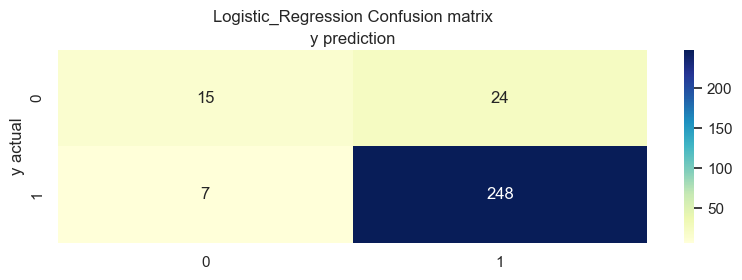

              precision    recall  f1-score   support

           2       0.68      0.38      0.49        39
           3       0.91      0.97      0.94       255

    accuracy                           0.89       294
   macro avg       0.80      0.68      0.72       294
weighted avg       0.88      0.89      0.88       294



In [25]:
from sklearn.metrics import classification_report


fig, ax = plt.subplots(figsize=(8, 3))
cm = metrics.confusion_matrix(y1_test,y_pred_lg)
sns.heatmap(metrics.confusion_matrix(y1_test,y_pred_lg),annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Logistic_Regression Confusion matrix', y=1.1)
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.xlabel('y prediction')
plt.ylabel('y actual')
plt.show()


print(classification_report(y1_test, y_pred_lg))